# 04 — Carga de Entrenamiento: TRIMP, Monotonía, Strain y Alertas

Este notebook implementa el modelo clásico de **Banister** para cuantificar
la carga de entrenamiento individual y detectar riesgo de sobreentrenamiento.

## Marco teórico

| Métrica | Definición | Por qué importa |
|---|---|---|
| **TRIMP** | `duración (min) × FC media × factor género` | Cuantifica el estrés fisiológico de cada sesión |
| **Monotonía** | `media₇d / std₇d` de TRIMP diario | Entrenar siempre igual aumenta el riesgo de lesión por acumulación sin recuperación |
| **Strain** | `TRIMP₇d acumulado × monotonía` | Combina volumen e irregularidad; el indicador más completo de sobrecarga |
| **Alerta** | `strain_max_semana > percentil 85 del atleta` | Umbral personalizado: compara al atleta consigo mismo, no con la población |

El **factor de género** (M=0.64, F=0.86) refleja diferencias en la respuesta
de lactato al esfuerzo cardíaco relativo (Foster et al., 2001).

**Fuentes:** `data/raw/runnnig-races-strava.csv` + `data/processed/athlete_clusters.csv`  
**Salida:** `data/processed/training_load.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

CLUSTER_LABELS = {
    0: "Recreacional",
    1: "Irregular rápido",
    2: "Trail / Montaña",
    3: "Alto volumen élite",
}
CLUSTER_COLORS = {0: "#E07B54", 1: "#4C72B0", 2: "#55A868", 3: "#8172B3"}

# Factor de género para TRIMP (Foster et al. 2001)
# Refleja diferencias en la respuesta de lactato al esfuerzo cardíaco relativo:
# las mujeres tienen mayor contribución aeróbica a igual FC → factor más alto.
GENDER_FACTOR = {"M": 0.64, "F": 0.86}

---
## 1. Carga, limpieza y TRIMP por actividad

In [2]:
RAW_PATH      = "../data/raw/runnnig-races-strava.csv"
CLUSTERS_PATH = "../data/processed/athlete_clusters.csv"

df_raw = pd.read_csv(
    RAW_PATH, sep=";",
    parse_dates=["timestamp"], dayfirst=True,
    dtype={"athlete": str, "gender": str},
)

df = df_raw.copy()
df["gender"] = df["gender"].str.strip().replace("", np.nan)
df = df.dropna(subset=["gender", "average heart rate (bpm)"])
df = df.rename(columns={
    "distance (m)":             "distance_m",
    "elapsed time (s)":         "elapsed_s",
    "elevation gain (m)":       "elevation_m",
    "average heart rate (bpm)": "hr_bpm",
})
df = df[(df["distance_m"] > 0) & (df["elapsed_s"] > 0)]
df["distance_km"] = df["distance_m"] / 1000
df["elapsed_min"] = df["elapsed_s"] / 60
df["pace_min_km"] = df["elapsed_min"] / df["distance_km"]
df = df[(df["pace_min_km"] >= 2) & (df["pace_min_km"] <= 20)]
df = df.sort_values(["athlete", "timestamp"]).reset_index(drop=True)

# Join clusters
clusters = pd.read_csv(CLUSTERS_PATH)
clusters["athlete"] = clusters["athlete"].astype(str)
df = df.merge(clusters[["athlete", "cluster", "cluster_label"]], on="athlete", how="left")
df = df.dropna(subset=["cluster"])
df["cluster"] = df["cluster"].astype(int)

# ── TRIMP por actividad ────────────────────────────────────────────────────────
# Fórmula: duración (min) × FC media (bpm) × factor_género
# Produce una unidad adimensional de "carga fisiológica" comparable entre sesiones.
df["gender_factor"] = df["gender"].map(GENDER_FACTOR)
df["trimp"] = df["elapsed_min"] * df["hr_bpm"] * df["gender_factor"]

df["date"] = df["timestamp"].dt.date

print(f"Actividades: {len(df):,}  |  Atletas: {df['athlete'].nunique()}")
print(f"\nTRIMP — media: {df['trimp'].mean():.0f}  |  mediana: {df['trimp'].median():.0f}  |  max: {df['trimp'].max():.0f}")
df[["athlete", "timestamp", "elapsed_min", "hr_bpm", "gender_factor", "trimp"]].head(4)

Actividades: 23,318  |  Atletas: 105

TRIMP — media: 6942  |  mediana: 5720  |  max: 137748


,athlete,timestamp,elapsed_min,hr_bpm,gender_factor,trimp
0,10305317,2017-07-15 08:25:00,89.616667,141.8,0.86,10928.573267
1,10305317,2017-07-16 08:23:00,116.850000,134.6,0.86,13526.088600
2,10305317,2017-07-27 16:55:00,48.833333,162.4,0.86,6820.258667
3,10305317,2017-08-13 08:03:00,108.366667,138.1,0.86,12870.275533


---
## 2. Serie diaria con días de descanso explícitos

La **monotonía** se calcula como `media₇d / std₇d` del TRIMP diario.
Para que la desviación estándar refleje correctamente los días de descanso,
necesitamos que esos días estén presentes en la serie con `trimp = 0`, no ausentes.

Sin este paso, una semana con 3 sesiones muy intensas y 4 días de descanso tendría
exactamente la misma std que una semana con 7 sesiones moderadas, lo cual es incorrecto.

In [3]:
# Agregamos TRIMP por atleta + día (puede haber >1 sesión por día)
daily_sessions = (
    df.groupby(["athlete", "date"], as_index=False)
    .agg(
        trimp_day     = ("trimp",         "sum"),
        gender        = ("gender",        "first"),
        cluster       = ("cluster",       "first"),
        cluster_label = ("cluster_label", "first"),
    )
)
daily_sessions["date"] = pd.to_datetime(daily_sessions["date"])

# Expandir el calendario de cada atleta para incluir días sin entrenamiento
daily_chunks = []
for ath, grp in daily_sessions.groupby("athlete"):
    full_idx = pd.date_range(grp["date"].min(), grp["date"].max(), freq="D")
    expanded = (
        grp.set_index("date")
        .reindex(full_idx)
        .reset_index()
        .rename(columns={"index": "date"})
    )
    expanded["athlete"]       = ath
    expanded["trimp_day"]     = expanded["trimp_day"].fillna(0.0)
    # Los metadatos son constantes por atleta → forward fill
    expanded["gender"]        = grp["gender"].iloc[0]
    expanded["cluster"]       = grp["cluster"].iloc[0]
    expanded["cluster_label"] = grp["cluster_label"].iloc[0]
    daily_chunks.append(expanded)

daily = pd.concat(daily_chunks, ignore_index=True)
daily = daily.sort_values(["athlete", "date"]).reset_index(drop=True)

n_rest = (daily["trimp_day"] == 0).sum()
print(f"Filas diarias (incluyendo descansos): {len(daily):,}")
print(f"Días de descanso: {n_rest:,}  ({n_rest/len(daily):.1%} del total)")

Filas diarias (incluyendo descansos): 109,350
Días de descanso: 87,686  (80.2% del total)


---
## 3. Monotonía y Strain (ventana rolling de 7 días)

### Monotonía
`monotony = mean₇d(trimp_day) / std₇d(trimp_day)`

- **Alta monotonía (>2)**: el atleta entrena casi igual todos los días, sin variación.
  Sin picos ni recuperaciones → riesgo de sobreentrenamiento crónico.
- **Baja monotonía (<1)**: alta variabilidad diaria, típico de planes periodizados bien estructurados.

### Strain
`strain = TRIMP_acumulado₇d × monotonía`

El strain multiplica el volumen total por su distribución:
la misma carga semanal produce más strain si se distribuye monótonamente
que si incluye un día de descanso claro entre sesiones.

**Implementación:** usamos ventana rolling de 7 días causal (sin look-ahead).
`min_periods=3` evita NaN en atletas con pocos días de historia.

In [4]:
def rolling_by_athlete(series: pd.Series, window: int, func: str, min_periods: int = 3) -> pd.Series:
    """Aplica una función rolling dentro de cada atleta de forma vectorizada."""
    return series.groupby(daily["athlete"]).transform(
        lambda x: getattr(x.rolling(window, min_periods=min_periods), func)()
    )

# ── Media y std de 7 días (causal: solo datos pasados) ────────────────────────
daily["roll7_mean"] = rolling_by_athlete(daily["trimp_day"], 7, "mean")
daily["roll7_std"]  = rolling_by_athlete(daily["trimp_day"], 7, "std")
daily["roll7_sum"]  = rolling_by_athlete(daily["trimp_day"], 7, "sum")

# Monotonía: std=0 ocurre cuando todos los días de la ventana tienen el mismo valor
# (e.g., 7 días de descanso). Clip a 1e-3 para evitar infinitos.
daily["monotony"] = daily["roll7_mean"] / daily["roll7_std"].clip(lower=1e-3)

# Strain
daily["strain"] = daily["roll7_sum"] * daily["monotony"]

# Descartar filas sin suficiente historia (primeros días de cada atleta)
n_before = len(daily)
daily = daily.dropna(subset=["monotony"]).reset_index(drop=True)
print(f"Filas descartadas por ventana insuficiente: {n_before - len(daily):,}")
print(f"\nMonotonía — media: {daily['monotony'].mean():.2f}  |  p95: {daily['monotony'].quantile(0.95):.2f}")
print(f"Strain    — media: {daily['strain'].mean():.0f}   |  p95: {daily['strain'].quantile(0.95):.0f}")

Filas descartadas por ventana insuficiente: 208

Monotonía — media: 0.37  |  p95: 0.99
Strain    — media: 7352   |  p95: 29242


---
## 4. Agregación semanal y alerta de sobreentrenamiento

### ¿Por qué percentil 85 y no un umbral fijo?

Un umbral absoluto de strain (e.g., >50.000) penalizaría injustamente a los atletas
de alto volumen y sería irrelevante para los recreacionales. Al usar el **percentil 85
del propio atleta**, la alerta significa: *"esta semana tu strain está entre las más altas
de tu historial"*, independientemente del nivel absoluto.

In [5]:
daily["week"] = daily["date"].dt.to_period("W")

weekly = (
    daily.groupby(["athlete", "week"], as_index=False)
    .agg(
        trimp_week    = ("trimp_day",  "sum"),       # TRIMP acumulado de la semana
        monotony_mean = ("monotony",   "mean"),      # monotonía media de la semana
        monotony_max  = ("monotony",   "max"),       # pico de monotonía
        strain_max    = ("strain",     "max"),       # pico de strain (el más peligroso)
        strain_mean   = ("strain",     "mean"),
        training_days = ("trimp_day",  lambda x: (x > 0).sum()),  # días activos
        gender        = ("gender",     "first"),
        cluster       = ("cluster",    "first"),
        cluster_label = ("cluster_label", "first"),
    )
)
weekly["week_start"] = weekly["week"].dt.to_timestamp()

# ── Alerta de sobreentrenamiento: strain_max > p85 del propio atleta ──────────
# Se calcula sobre el historial completo del atleta disponible en el dataset.
# En un sistema en producción se actualizaría semana a semana.
weekly["strain_p85"] = (
    weekly.groupby("athlete")["strain_max"]
    .transform(lambda x: x.quantile(0.85))
)
weekly["alert_overtraining"] = weekly["strain_max"] > weekly["strain_p85"]

n_alerts = weekly["alert_overtraining"].sum()
alert_rate = weekly["alert_overtraining"].mean()
print(f"Semanas totales: {len(weekly):,}")
print(f"Alertas generadas: {n_alerts:,}  ({alert_rate:.1%})")
print(f"  — Esperado teórico: ~15% (percentil 85)\n")

# Resumen por cluster
summary = weekly.groupby("cluster_label").agg(
    trimp_media=("trimp_week",    "median"),
    monotony   =("monotony_mean", "median"),
    strain_med =("strain_max",    "median"),
    alertas    =("alert_overtraining", "mean"),
    semanas    =("week",          "count"),
).round(2)
summary["alertas"] = summary["alertas"].map("{:.1%}".format)
summary

Semanas totales: 15,660
Alertas generadas: 2,246  (14.3%)
  — Esperado teórico: ~15% (percentil 85)



,trimp_media,monotony,strain_med,alertas,semanas
cluster_label,,,,,
Alto volumen élite,14212.03,0.59,15679.94,15.0%,4568
Irregular rápido,0.00,0.05,1311.07,13.0%,6738
Recreacional,8281.46,0.38,7622.63,15.0%,1537
Trail / Montaña,9109.79,0.40,9829.81,15.0%,2817


---
## 5. Guardar resultado

Exportamos la tabla semanal a `data/processed/training_load.csv`
para uso en notebooks de coaching personalizado o dashboards.

In [6]:
import os
os.makedirs("../data/processed", exist_ok=True)

OUT_PATH = "../data/processed/training_load.csv"

export_cols = [
    "athlete", "week", "week_start", "gender", "cluster", "cluster_label",
    "trimp_week", "training_days",
    "monotony_mean", "monotony_max",
    "strain_max", "strain_mean",
    "strain_p85", "alert_overtraining",
]
weekly[export_cols].to_csv(OUT_PATH, index=False)

print(f"Guardado: {OUT_PATH}  ({len(weekly):,} filas × {len(export_cols)} columnas)")
weekly[export_cols].head(3)

Guardado: ../data/processed/training_load.csv  (15,660 filas × 14 columnas)


,athlete,week,week_start,gender,cluster,cluster_label,trimp_week,training_days,monotony_mean,monotony_max,strain_max,strain_mean,strain_p85,alert_overtraining
0,10305317,2017-07-17/2017-07-23,2017-07-17,F,0,Recreacional,0.000000,0,0.616375,1.135642,27771.733751,14483.146389,19424.55526,True
1,10305317,2017-07-24/2017-07-30,2017-07-24,F,0,Recreacional,6820.258667,1,0.215980,0.377964,2577.815473,1473.037413,19424.55526,False
2,10305317,2017-07-31/2017-08-06,2017-07-31,F,0,Recreacional,0.000000,0,0.161985,0.377964,2577.815473,1104.778060,19424.55526,False


---
## 6. Visualizaciones por atleta representativo

Seleccionamos el atleta con más semanas de historia en cada cluster
para tener la serie temporal más rica y representativa de cada perfil.

In [7]:
# Un atleta con más semanas de historia por cluster
rep_athletes = (
    weekly.groupby(["cluster", "athlete"])["week"]
    .count()
    .reset_index()
    .sort_values(["cluster", "week"], ascending=[True, False])
    .groupby("cluster")
    .first()
    .reset_index()
    .rename(columns={"week": "n_weeks"})
)

print("Atletas representativos seleccionados:")
for _, row in rep_athletes.iterrows():
    label = CLUSTER_LABELS[int(row["cluster"])]
    alerts = weekly[(weekly["athlete"] == row["athlete"]) & weekly["alert_overtraining"]].shape[0]
    print(f"  C{int(row['cluster'])} {label:22s}: atleta {row['athlete']}  ({row['n_weeks']} semanas, {alerts} alertas)")

Atletas representativos seleccionados:
  C0 Recreacional          : atleta 11088529  (200 semanas, 29 alertas)
  C1 Irregular rápido      : atleta 6583234  (1025 semanas, 28 alertas)
  C2 Trail / Montaña       : atleta 5688059  (279 semanas, 42 alertas)
  C3 Alto volumen élite    : atleta 3573750  (381 semanas, 57 alertas)


### 6.1 Panel completo por atleta: TRIMP · Monotonía · Strain + Alertas

Cada panel tiene 3 subplots apilados con el mismo eje X (tiempo) para leer
la relación causal entre ellos: un pico de TRIMP (↑ carga) seguido de alta
monotonía (↑ homogeneidad) produce el pico de strain que dispara la alerta.

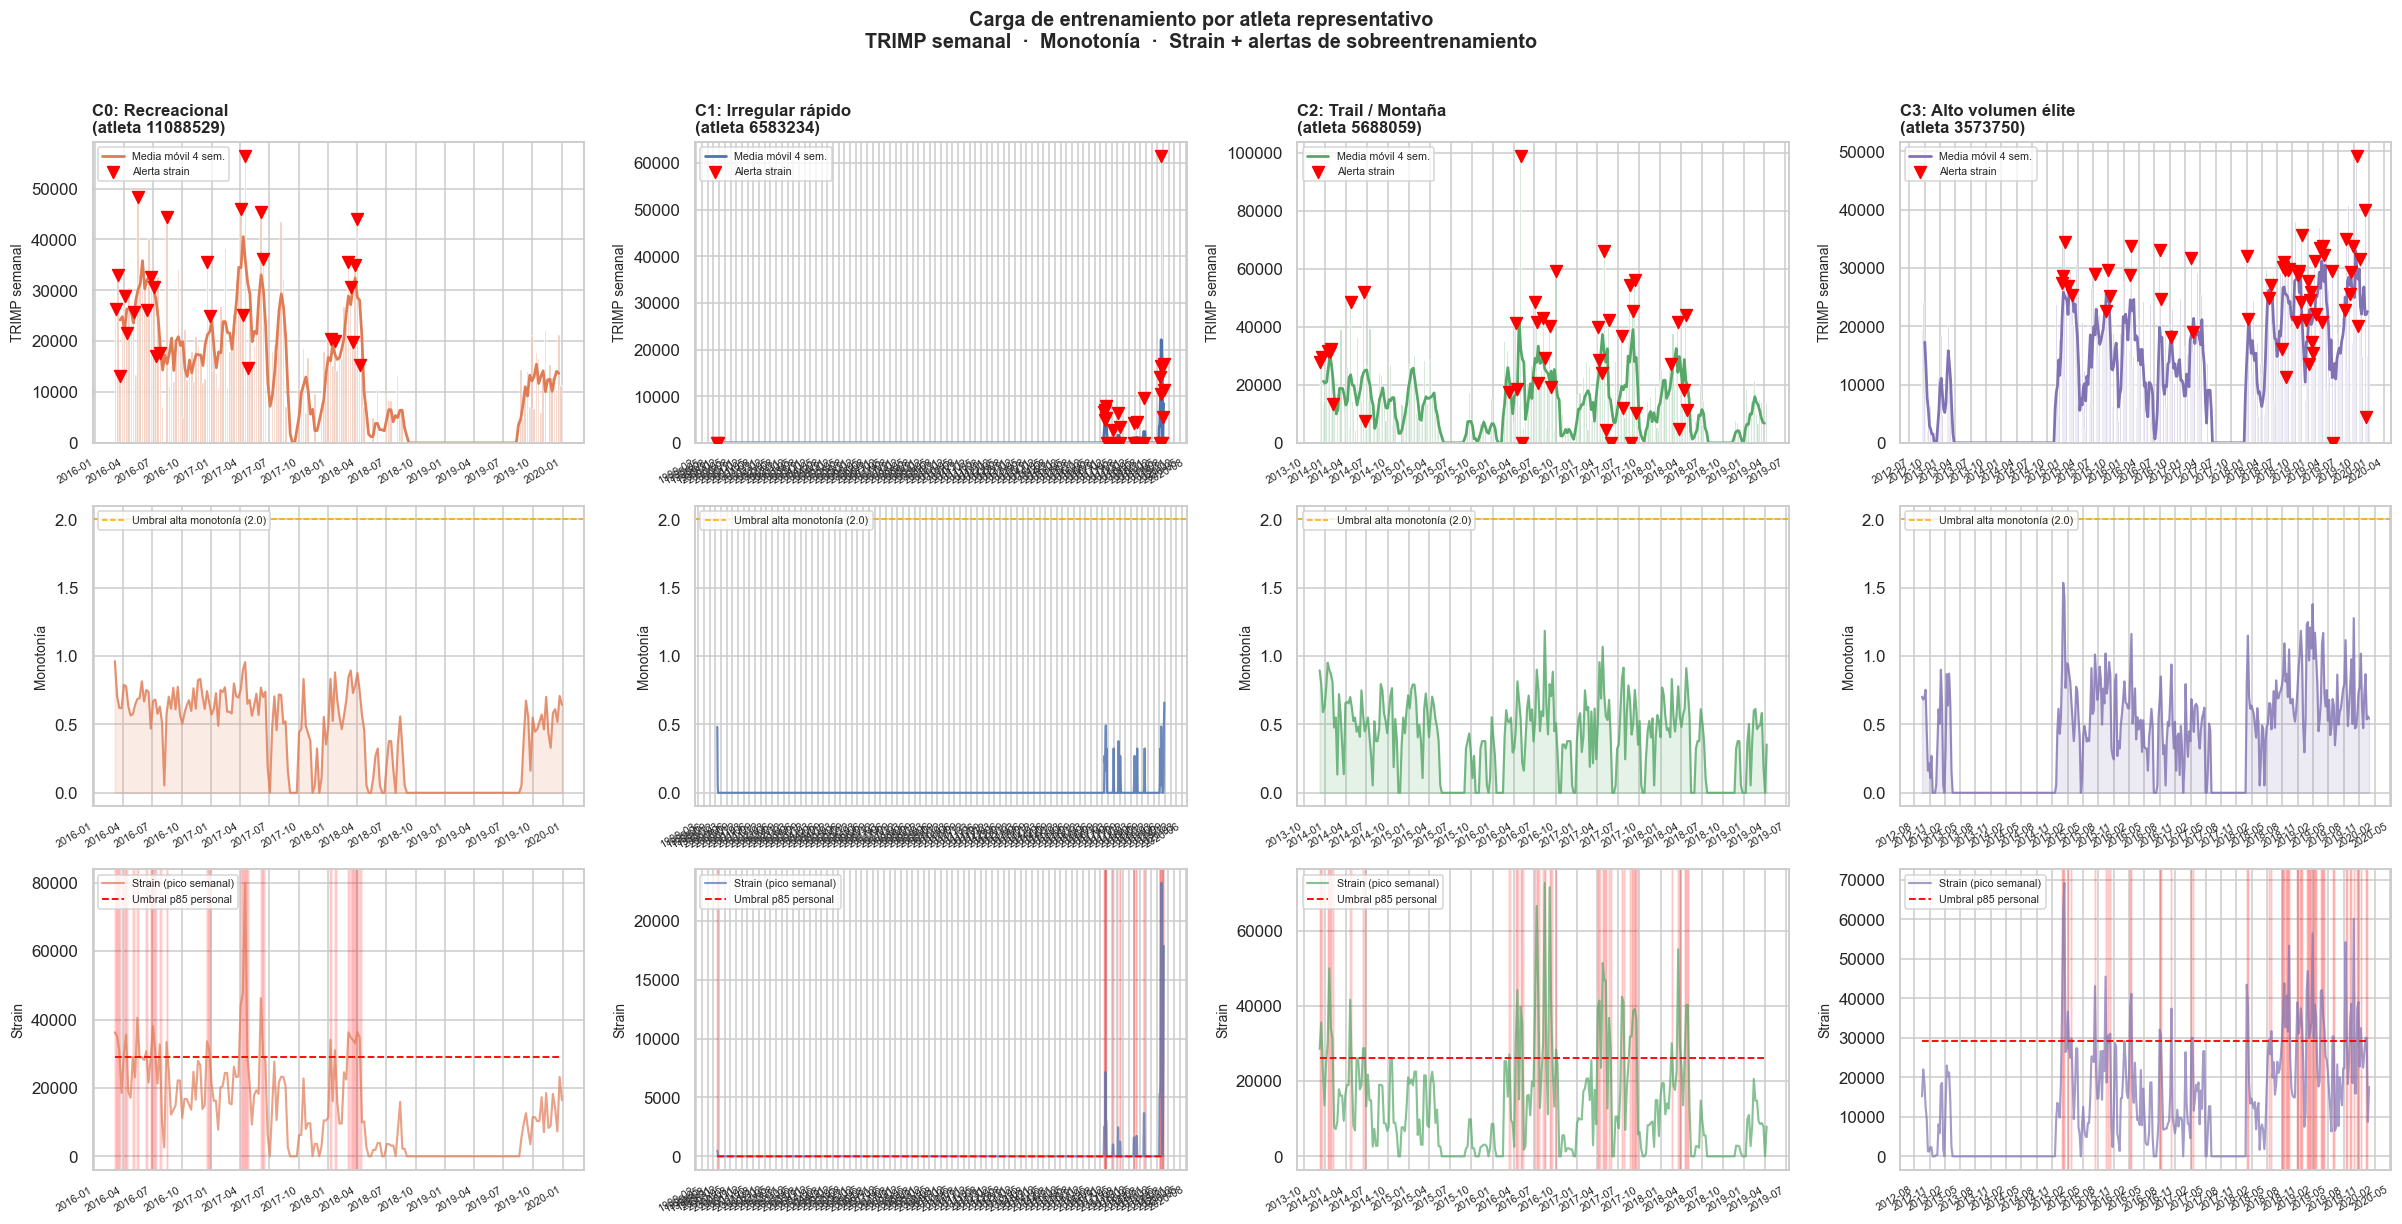

In [8]:
def plot_athlete_load(ax_trimp, ax_mono, ax_strain, ath_data, color, title):
    """
    Dibuja los 3 subplots de carga para un atleta.
    ath_data: DataFrame semanal ya filtrado por atleta, ordenado por week_start.
    """
    dates  = ath_data["week_start"]
    alerts = ath_data["alert_overtraining"]

    # ── TRIMP semanal ─────────────────────────────────────────────────────────
    ax_trimp.bar(dates, ath_data["trimp_week"], width=5, color=color, alpha=0.6)
    ax_trimp.plot(dates, ath_data["trimp_week"].rolling(4, center=True).mean(),
                  color=color, linewidth=1.8, label="Media móvil 4 sem.")
    # Marcar semanas con alerta
    ax_trimp.scatter(dates[alerts], ath_data.loc[alerts, "trimp_week"],
                     marker="v", color="red", s=60, zorder=5, label="Alerta strain")
    ax_trimp.set_ylabel("TRIMP semanal", fontsize=9)
    ax_trimp.set_title(title, fontsize=11, fontweight="bold", loc="left")
    ax_trimp.legend(fontsize=7, loc="upper left")
    ax_trimp.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax_trimp.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax_trimp.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)

    # ── Monotonía ─────────────────────────────────────────────────────────────
    ax_mono.plot(dates, ath_data["monotony_mean"], color=color, linewidth=1.4, alpha=0.8)
    ax_mono.fill_between(dates, ath_data["monotony_mean"], alpha=0.15, color=color)
    # Umbral de alta monotonía (>2 = zona de riesgo según literatura)
    ax_mono.axhline(2.0, color="orange", linestyle="--", linewidth=1,
                    label="Umbral alta monotonía (2.0)")
    ax_mono.set_ylabel("Monotonía", fontsize=9)
    ax_mono.legend(fontsize=7, loc="upper left")
    ax_mono.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax_mono.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax_mono.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)

    # ── Strain + p85 + alertas ────────────────────────────────────────────────
    ax_strain.plot(dates, ath_data["strain_max"], color=color, linewidth=1.4,
                   alpha=0.7, label="Strain (pico semanal)")
    ax_strain.plot(dates, ath_data["strain_p85"], color="red", linestyle="--",
                   linewidth=1.2, label="Umbral p85 personal")
    # Sombreado de alertas
    for _, row in ath_data[alerts].iterrows():
        ax_strain.axvspan(row["week_start"],
                          row["week_start"] + pd.Timedelta(days=6),
                          color="red", alpha=0.12)
    ax_strain.set_ylabel("Strain", fontsize=9)
    ax_strain.legend(fontsize=7, loc="upper left")
    ax_strain.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax_strain.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax_strain.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)


# ── Figura principal: 4 atletas × 3 métricas ──────────────────────────────────
n_athletes = len(rep_athletes)
fig, axes = plt.subplots(
    3, n_athletes,
    figsize=(5.5 * n_athletes, 11),
    sharex=False,
)
fig.suptitle(
    "Carga de entrenamiento por atleta representativo\n"
    "TRIMP semanal  ·  Monotonía  ·  Strain + alertas de sobreentrenamiento",
    fontsize=13, fontweight="bold", y=1.01,
)

for col, (_, row) in enumerate(rep_athletes.iterrows()):
    ath   = row["athlete"]
    c     = int(row["cluster"])
    color = CLUSTER_COLORS[c]
    label = CLUSTER_LABELS[c]

    ath_data = (
        weekly[weekly["athlete"] == ath]
        .sort_values("week_start")
        .reset_index(drop=True)
    )

    plot_athlete_load(
        ax_trimp  = axes[0, col],
        ax_mono   = axes[1, col],
        ax_strain = axes[2, col],
        ath_data  = ath_data,
        color     = color,
        title     = f"C{c}: {label}\n(atleta {ath})",
    )

plt.tight_layout()
plt.show()

### 6.2 Distribución de métricas por cluster

Comparamos TRIMP, monotonía y strain entre clusters para ver si los perfiles
de entrenamiento producen patrones de carga distintos y si algunos clusters
tienen mayor riesgo estructural de sobreentrenamiento.

/var/folders/sz/tcwshbld2ks22flzhl8_rqfh0000gn/T/ipykernel_34950/1385113201.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/sz/tcwshbld2ks22flzhl8_rqfh0000gn/T/ipykernel_34950/1385113201.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)
/var/folders/sz/tcwshbld2ks22flzhl8_rqfh0000gn/T/ipykernel_34950/1385113201.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/sz/tcwshbld2ks22flzhl8_rqfh0000gn/T/ipykernel_34950/1385113201.py:23: UserWarning: set_ticklabels() should only be used with a f

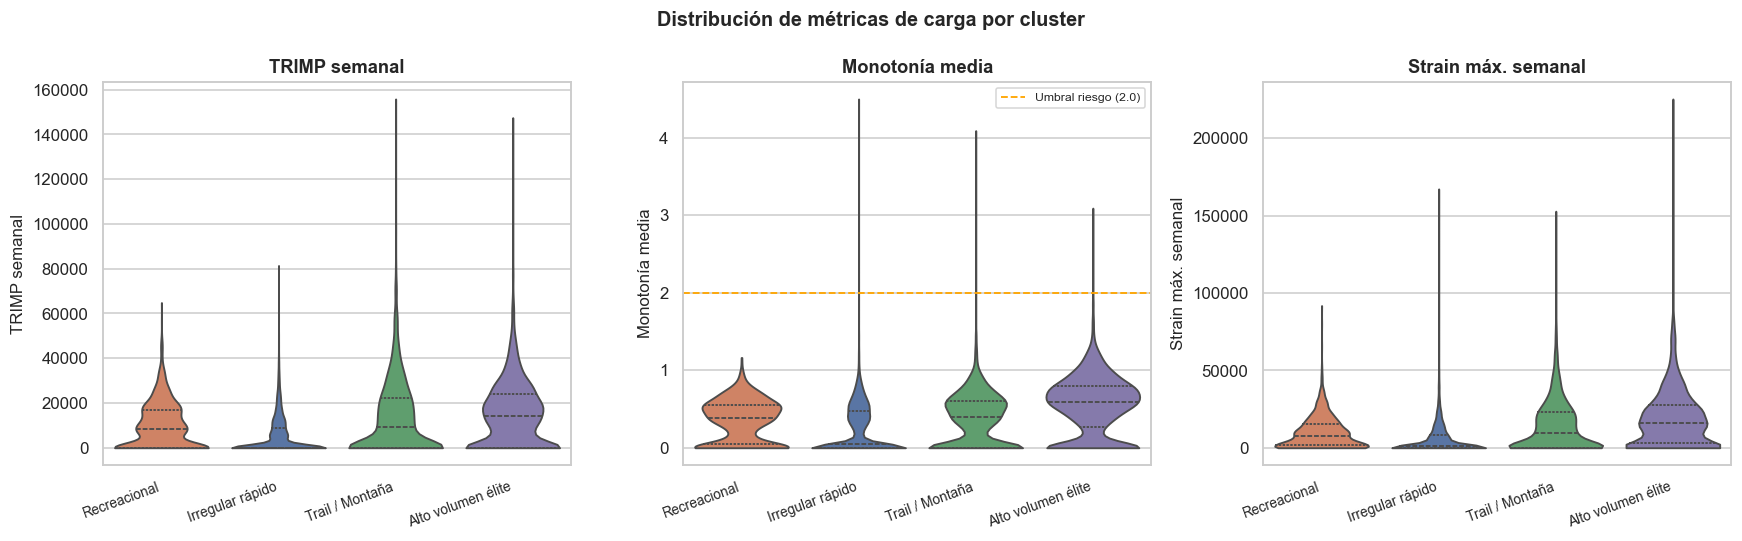

In [9]:
# ── Gráfico: violinplots de TRIMP, monotonía y strain por cluster ─────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ("trimp_week",    "TRIMP semanal",        None),
    ("monotony_mean", "Monotonía media",       2.0),   # umbral riesgo
    ("strain_max",    "Strain máx. semanal",  None),
]

order = [CLUSTER_LABELS[c] for c in sorted(CLUSTER_LABELS)]
palette = {CLUSTER_LABELS[c]: CLUSTER_COLORS[c] for c in CLUSTER_LABELS}

for ax, (col, label, threshold) in zip(axes, metrics):
    sns.violinplot(
        data=weekly, x="cluster_label", y=col,
        order=order, palette=palette,
        inner="quartile", cut=0, ax=ax,
        density_norm="width",
    )
    ax.set_xlabel("")
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)
    if threshold is not None:
        ax.axhline(threshold, color="orange", linestyle="--",
                   linewidth=1.2, label=f"Umbral riesgo ({threshold})")
        ax.legend(fontsize=8)

fig.suptitle("Distribución de métricas de carga por cluster", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.3 Tasa de alertas por cluster y estacionalidad

¿Hay meses del año con más alertas? Los atletas de trail suelen acumular
en primavera (preparación de carreras de verano), los de carretera en otoño.

/var/folders/sz/tcwshbld2ks22flzhl8_rqfh0000gn/T/ipykernel_34950/586869243.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha="right", fontsize=9)


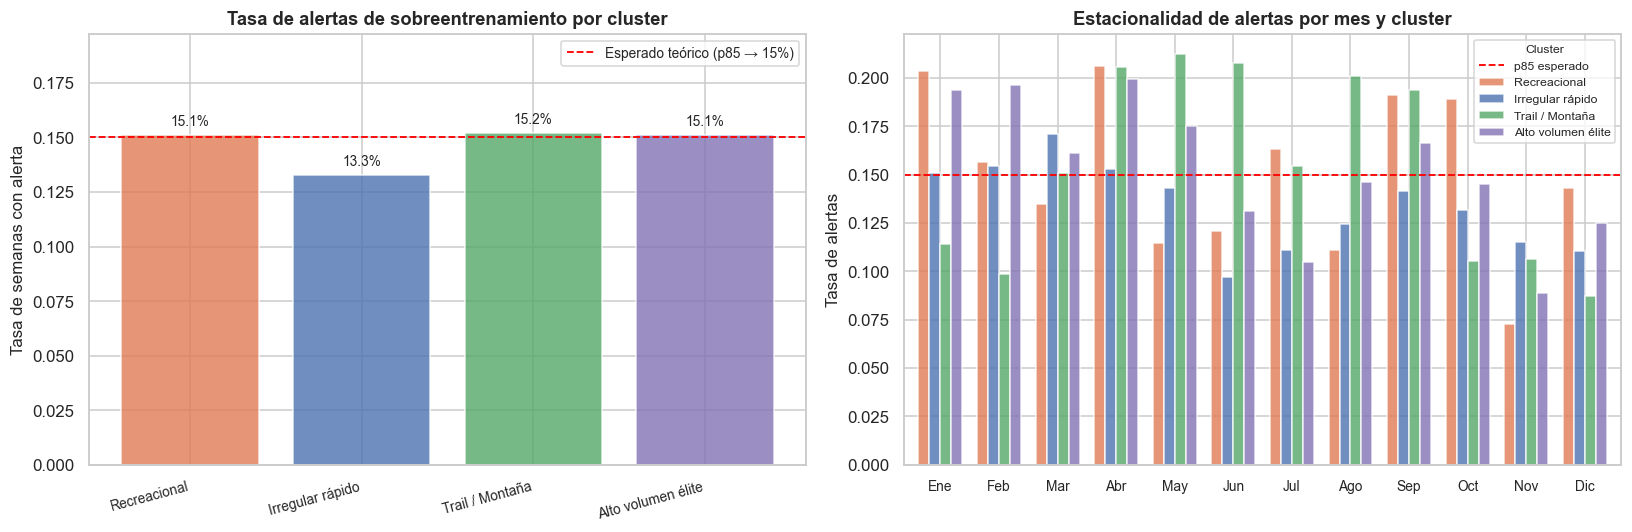

In [10]:
weekly["month"] = weekly["week_start"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Tasa de alertas por cluster ────────────────────────────────────────────────
alert_by_cluster = (
    weekly.groupby("cluster_label")["alert_overtraining"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "alertas", "count": "semanas"})
    .assign(tasa=lambda d: d["alertas"] / d["semanas"])
    .loc[order]   # mismo orden que los violinplots
)

bars = axes[0].bar(
    alert_by_cluster.index,
    alert_by_cluster["tasa"],
    color=[palette[l] for l in alert_by_cluster.index],
    alpha=0.8, edgecolor="white",
)
axes[0].axhline(0.15, color="red", linestyle="--", linewidth=1.2,
                label="Esperado teórico (p85 → 15%)")
for bar, (_, row) in zip(bars, alert_by_cluster.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f"{row['tasa']:.1%}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("Tasa de semanas con alerta", fontsize=11)
axes[0].set_title("Tasa de alertas de sobreentrenamiento por cluster", fontsize=12, fontweight="bold")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha="right", fontsize=9)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, alert_by_cluster["tasa"].max() * 1.3)

# ── Estacionalidad de alertas por mes ─────────────────────────────────────────
# Pivotamos: mes × cluster → tasa de alertas
seasonal = (
    weekly.groupby(["month", "cluster_label"])["alert_overtraining"]
    .mean()
    .unstack("cluster_label")
    .reindex(columns=order)
)
month_names = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
seasonal.index = [month_names[m - 1] for m in seasonal.index]

seasonal.plot(
    kind="bar", ax=axes[1],
    color=[palette[l] for l in order],
    alpha=0.8, edgecolor="white", width=0.75,
)
axes[1].axhline(0.15, color="red", linestyle="--", linewidth=1.2, label="p85 esperado")
axes[1].set_ylabel("Tasa de alertas", fontsize=11)
axes[1].set_xlabel("")
axes[1].set_title("Estacionalidad de alertas por mes y cluster", fontsize=12, fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, fontsize=9)
axes[1].legend(title="Cluster", fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

### 6.4 Relación monotonía – strain (scatter por cluster)

Validamos la coherencia interna del modelo: el strain debería crecer con la monotonía
(mismo TRIMP distribuido de forma más homogénea → más strain). Si el scatter muestra
una nube sin estructura, habría un problema en el cálculo.

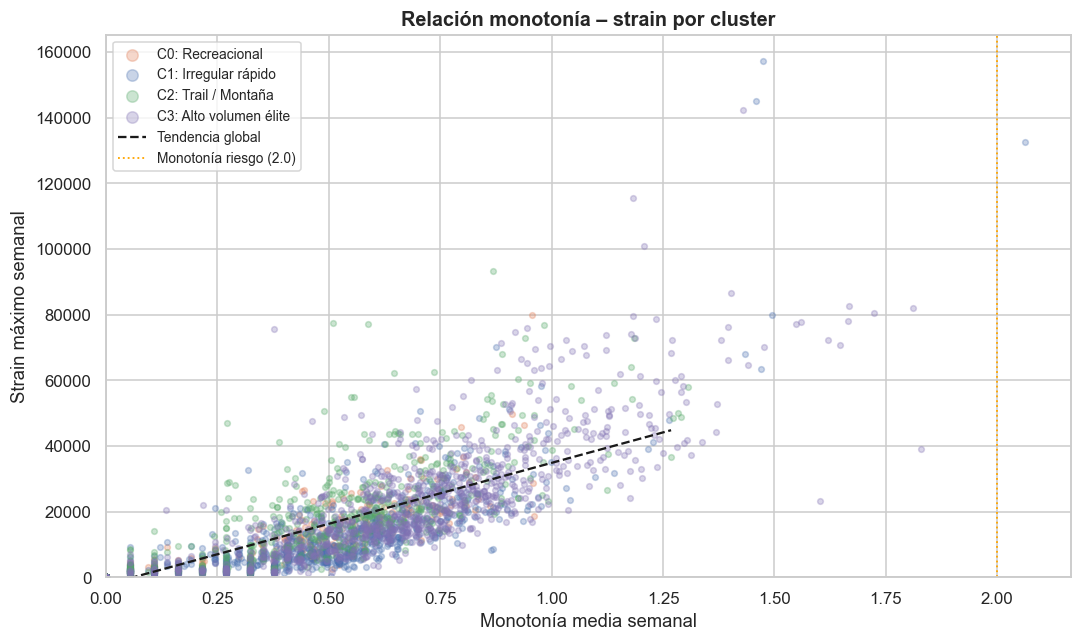

Correlación de Pearson (monotonía, strain): 0.829


In [11]:
# ── Scatter monotonía vs strain, coloreado por cluster ────────────────────────
# Muestra aleatoria para no saturar con 15k puntos
sample = weekly.sample(n=min(4000, len(weekly)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

for c, label in CLUSTER_LABELS.items():
    mask = sample["cluster"] == c
    ax.scatter(
        sample.loc[mask, "monotony_mean"],
        sample.loc[mask, "strain_max"],
        color=CLUSTER_COLORS[c], alpha=0.3, s=14,
        label=f"C{c}: {label}",
    )

# Línea de tendencia global (polyfit)
valid = sample.dropna(subset=["monotony_mean", "strain_max"])
z = np.polyfit(valid["monotony_mean"], valid["strain_max"], 1)
x_line = np.linspace(valid["monotony_mean"].quantile(0.01),
                     valid["monotony_mean"].quantile(0.99), 100)
ax.plot(x_line, np.polyval(z, x_line), "k--", linewidth=1.5, label="Tendencia global")

ax.axvline(2.0, color="orange", linestyle=":", linewidth=1.2, label="Monotonía riesgo (2.0)")
ax.set_xlabel("Monotonía media semanal", fontsize=12)
ax.set_ylabel("Strain máximo semanal", fontsize=12)
ax.set_title("Relación monotonía – strain por cluster", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, markerscale=2)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

# Correlación
corr = weekly[["monotony_mean", "strain_max"]].corr().iloc[0, 1]
print(f"Correlación de Pearson (monotonía, strain): {corr:.3f}")

---
## 7. Conclusiones e implicaciones para el coaching

### Interpretación por cluster

| Cluster | TRIMP mediana | Monotonía | Riesgo principal |
|---|---|---|---|
| **Recreacional** | Bajo | Variable | Picos bruscos de carga (CV alto) tras semanas de inactividad |
| **Irregular rápido** | Medio | Alta variabilidad | Alternancia extrema carga/descanso → picos de strain aislados |
| **Trail / Montaña** | Medio-alto | Moderada | Desnivel acumula TRIMP real mayor que el aparente → posible subestimación |
| **Alto volumen élite** | Alto | Baja (bien periodizado) | Umbral p85 más alto en valor absoluto; riesgo cuando rompe rutina |

### Limitaciones del TRIMP simplificado

1. **Sin FC de reserva**: la fórmula completa de Banister usa `(FC_media - FC_reposo) / (FC_max - FC_reposo)`,
   normalización que no podemos hacer sin FC en reposo y FC máxima por atleta.
2. **Sensible a la duración**: sesiones muy largas a baja intensidad generan TRIMP alto.
   El **TSS (Training Stress Score)** de Coggan/Allen es más preciso para running.
3. **El p85 evoluciona**: en producción el umbral debe recalcularse con ventana deslizante
   (e.g., últimas 12 semanas) en lugar de sobre todo el historial.

### Próximos pasos sugeridos
- `05_coach_recommendations.ipynb` — generación automática de recomendaciones de carga
  para la semana siguiente usando el cluster, el strain actual y el ATL.
- Integrar las alertas con un dashboard en tiempo real (Streamlit / Dash).